In [234]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os 

In [235]:
country_continent = pd.read_csv('countryContinent.csv', encoding='ISO-8859-1')
recipes_df = pd.read_csv('recipes_df_with_eco_scores_and_luxury_scores.csv', index_col=0)

In [236]:
country_continent

,country,code_2,code_3,country_code,iso_3166_2,continent,sub_region,region_code,sub_region_code
0,Afghanistan,AF,AFG,4,ISO 3166-2:AF,Asia,Southern Asia,142.0,34.0
1,Åland Islands,AX,ALA,248,ISO 3166-2:AX,Europe,Northern Europe,150.0,154.0
2,Albania,AL,ALB,8,ISO 3166-2:AL,Europe,Southern Europe,150.0,39.0
3,Algeria,DZ,DZA,12,ISO 3166-2:DZ,Africa,Northern Africa,2.0,15.0
4,American Samoa,AS,ASM,16,ISO 3166-2:AS,Oceania,Polynesia,9.0,61.0
...,...,...,...,...,...,...,...,...,...
244,Wallis and Futuna,WF,WLF,876,ISO 3166-2:WF,Oceania,Polynesia,9.0,61.0
245,Western Sahara,EH,ESH,732,ISO 3166-2:EH,Africa,Northern Africa,2.0,15.0
246,Yemen,YE,YEM,887,ISO 3166-2:YE,Asia,Western Asia,142.0,145.0
247,Zambia,ZM,ZMB,894,ISO 3166-2:ZM,Africa,Eastern Africa,2.0,14.0


In [237]:
# the values of "cuisine" in recipes_df that aren't in country_continent
cuisine_values = recipes_df['cuisine'].unique()
countries = country_continent['country'].unique()
missing_cuisines = set(cuisine_values) - set(countries)
missing_cuisines

{'Korea, Republic of', 'United States', nan}

In [238]:
# printing the cuisine_values (that are't NaNs) that contain "korea"

# Filter out NaN values from cuisine_values
cuisine_values = [cuisine for cuisine in cuisine_values if pd.notna(cuisine)]
for cuisine in cuisine_values:
    if 'korea' in cuisine.lower():
        print(cuisine)

Korea, Republic of
Korea (Democratic People's Republic of)


In [239]:
# cheching if a country contains "korea" 
country_continent[country_continent["country"].str.contains("korea", case=False)]

,country,code_2,code_3,country_code,iso_3166_2,continent,sub_region,region_code,sub_region_code
117,Korea (Democratic People's Republic of),KP,PRK,408,ISO 3166-2:KP,Asia,Eastern Asia,142.0,30.0
118,Korea (Republic of),KR,KOR,410,ISO 3166-2:KR,Asia,Eastern Asia,142.0,30.0


In [240]:
country_continent[country_continent["country"].str.contains("United States", case=False)]

,country,code_2,code_3,country_code,iso_3166_2,continent,sub_region,region_code,sub_region_code
235,United States of America,US,USA,840,ISO 3166-2:US,Americas,Northern America,19.0,21.0
236,United States Minor Outlying Islands,UM,UMI,581,ISO 3166-2:UM,NaN,NaN,NaN,NaN


In [241]:
mapping = {
    "United States": "United States of America",
    "South Korea": "Korea (Republic of)"}

recipes_df['cuisine'] = recipes_df['cuisine'].replace(mapping)

In [242]:
# Merge recipes_df with country_continent on 'cuisine' ~ 'country'
recipes_with_codes = recipes_df.merge(
    country_continent[["country", "code_3"]],
    left_on="cuisine", right_on="country",
    how="left"
)

# Check how many were successfully matched
matched = recipes_with_codes["code_3"].notna().sum()
total = len(recipes_with_codes)
match_rate = round(matched / total * 100, 2)

matched, total, match_rate


(np.int64(3719), 4551, np.float64(81.72))

In [243]:
recipes_with_codes.head()

,title,steps,rating,comments,dish_type,cuisine,continent,sub_region,Calories,Fat,...,log_Fat,log_Carbs,log_Protein,ingredients_str,ingredients_cleaned,ingredient_semantics,eco_score,luxury_score,country,code_3
0,Homemade Lasagna,['Gather all ingredients.Dotdash Meredith Food...,4.6,[],Main dishes,Italy,Europe,Southern Europe,638.0,27.0,...,3.332205,4.007333,3.850148,ground pork lean ground beef onion tomato garl...,"['pork', 'beef', 'onion', 'tomato', 'garlic', ...","['meat', 'meat', 'aromatic', 'vegetable', 'aro...",152.8,2,Italy,ITA
1,Chicken Parmesan,['Gather the ingredients. Preheat an oven to 4...,4.8,[],Main dishes,Italy,Europe,Southern Europe,471.0,25.0,...,3.258097,3.258097,3.761200,breast halves salt eggs bread crumbs olive oil...,"['chicken breast', 'salt', 'egg', 'bread crumb...","['poultry', 'seasoning', 'egg', 'baked goods',...",22.0,0,Italy,ITA
2,Chicken Marsala,['Gather all ingredients.Dotdash Meredith Food...,4.6,[],Main dishes,Italy,Europe,Southern Europe,448.0,27.0,...,3.332205,2.639057,3.401197,purpose flour salt black pepper butter olive o...,"['flour', 'salt', 'black pepper', 'butter', 'o...","['flour', 'seasoning', 'spice', 'fat', 'fat', ...",30.4,0,Italy,ITA
3,Spaghetti Aglio e Olio,['Gather all ingredients.Dotdash Meredith Food...,4.7,[],Main dishes,Italy,Europe,Southern Europe,755.0,35.0,...,3.583519,4.477337,3.178054,uncooked spaghetti olive oil pepper flakes sal...,"['uncooked spaghetti', 'olive oil', 'pepper fl...","['pasta', 'fat', 'pepper flakes', 'seasoning',...",17.4,0,Italy,ITA
4,Shrimp Scampi with Pasta,"['Gather ingredients.', 'Bring a large pot of ...",4.6,[],Main dishes,Italy,Europe,Southern Europe,511.0,19.0,...,2.995732,4.077537,3.135494,linguine pasta butter shallots shrimp dry whit...,"['linguine pasta', 'butter', 'shallots', 'shri...","['pasta', 'fat', 'aromatic', 'seafood', 'bever...",23.7,1,Italy,ITA


In [244]:
hofstede_df = pd.read_excel("hofstedes Dimensions Data.xlsx")

In [245]:
CTR_TO_ISO = {
    "ALG": "DZA",  # Algeria
    "ANG": "AGO",  # Angola
    "AUL": "AUS",  # Australia
    "BAN": "BGD",  # Bangladesh
    "BOS": "BIH",  # Bosnia and Herzegovina
    "BUF": "BFA",  # Burkina Faso
    "BUL": "BGR",  # Bulgaria
    "CAP": "CPV",  # Cape Verde
    "CHI": "CHN",  # China
    "CRO": "HRV",  # Croatia
    "DEN": "DNK",  # Denmark
    "GER": "DEU",  # Germany
    "GRE": "GRC",  # Greece
    "HOK": "HKG",  # Hong Kong
    "ICE": "ISL",  # Iceland
    "IDO": "IDN",  # Indonesia
    "IRA": "IRN",  # Iran
    "IRE": "IRL",  # Ireland
    "LAT": "LVA",  # Latvia
    "LEB": "LBN",  # Lebanon
    "LIB": "LBR",  # Liberia
    "LIT": "LTU",  # Lithuania
    "MAL": "MYS",  # Malaysia
    "MOL": "MDA",  # Moldova
    "MOR": "MAR",  # Morocco
    "NET": "NLD",  # Netherlands
    "NIG": "NGA",  # Nigeria
    "PAR": "PRY",  # Paraguay
    "PHI": "PHL",  # Philippines
    "POR": "PRT",  # Portugal
    "PUE": "PRI",  # Puerto Rico
    "ROM": "ROU",  # Romania
    "SAF": "ZAF",  # South Africa
    "SAL": "SLV",  # El Salvador
    "SER": "SRB",  # Serbia
    "SIN": "SGP",  # Singapore
    "SLK": "SVK",  # Slovakia
    "SPA": "ESP",  # Spain
    "SWI": "CHE",  # Switzerland
    "TAI": "TWN",  # Taiwan
    "TAN": "TZA",  # Tanzania
    "TRI": "TTO",  # Trinidad and Tobago
    "URU": "URY",  # Uruguay
    "VIE": "VNM",  # Vietnam
    "ZAM": "ZMB"   # Zambia
}


In [246]:
hofstede_df["iso_alpha3"] = hofstede_df["ctr"].replace(CTR_TO_ISO)

merged_df = recipes_with_codes.merge(
    hofstede_df,
    left_on="code_3",
    right_on="iso_alpha3",
    how="left"
)


In [247]:
merged_df.columns

Index(['title', 'steps', 'rating', 'comments', 'dish_type', 'cuisine',
       'continent', 'sub_region', 'Calories', 'Fat', 'Carbs', 'Protein',
       'prep_time', 'cook_time', 'additional_time', 'total_time', 'servings',
       'ingredients', 'num_ingredients', 'num_steps', 'log_prep_time',
       'log_cook_time', 'log_additional_time', 'log_total_time',
       'log_Calories', 'log_Fat', 'log_Carbs', 'log_Protein',
       'ingredients_str', 'ingredients_cleaned', 'ingredient_semantics',
       'eco_score', 'luxury_score', 'country_x', 'code_3', 'ctr', 'country_y',
       'pdi', 'idv', 'mas', 'uai', 'ltowvs', 'ivr', 'estim', 'Unnamed: 9',
       'Unnamed: 10', 'iso_alpha3'],
      dtype='object')

In [248]:
merged_df.drop(columns=["Unnamed: 9", "Unnamed: 10"], inplace=True)
merged_df

,title,steps,rating,comments,dish_type,cuisine,continent,sub_region,Calories,Fat,...,ctr,country_y,pdi,idv,mas,uai,ltowvs,ivr,estim,iso_alpha3
0,Homemade Lasagna,['Gather all ingredients.Dotdash Meredith Food...,4.6,[],Main dishes,Italy,Europe,Southern Europe,638.0,27.0,...,ITA,Italy,50.0,76.0,70.0,75.0,61.460957,29.687500,0.0,ITA
1,Chicken Parmesan,['Gather the ingredients. Preheat an oven to 4...,4.8,[],Main dishes,Italy,Europe,Southern Europe,471.0,25.0,...,ITA,Italy,50.0,76.0,70.0,75.0,61.460957,29.687500,0.0,ITA
2,Chicken Marsala,['Gather all ingredients.Dotdash Meredith Food...,4.6,[],Main dishes,Italy,Europe,Southern Europe,448.0,27.0,...,ITA,Italy,50.0,76.0,70.0,75.0,61.460957,29.687500,0.0,ITA
3,Spaghetti Aglio e Olio,['Gather all ingredients.Dotdash Meredith Food...,4.7,[],Main dishes,Italy,Europe,Southern Europe,755.0,35.0,...,ITA,Italy,50.0,76.0,70.0,75.0,61.460957,29.687500,0.0,ITA
4,Shrimp Scampi with Pasta,"['Gather ingredients.', 'Bring a large pot of ...",4.6,[],Main dishes,Italy,Europe,Southern Europe,511.0,19.0,...,ITA,Italy,50.0,76.0,70.0,75.0,61.460957,29.687500,0.0,ITA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4558,Vietnamese/Chinese Pork Chops,"['Whisk together the brown sugar, honey, fish ...",4.3,[],NaN,Viet Nam,Asia,Southeast Asia,416.0,29.0,...,VIE,Vietnam,70.0,20.0,40.0,30.0,57.178841,35.491071,0.0,VNM
4559,Spicy Vietnamese Beef Noodle Soup,['Heat oil in a large pot over medium-high hea...,4.5,[],NaN,Viet Nam,Asia,Southeast Asia,390.0,15.0,...,VIE,Vietnam,70.0,20.0,40.0,30.0,57.178841,35.491071,0.0,VNM
4560,Vietnamese-Style Chicken Curry Soup,['Heat oil in a large stockpot over medium hea...,4.6,[],NaN,Viet Nam,Asia,Southeast Asia,512.0,27.0,...,VIE,Vietnam,70.0,20.0,40.0,30.0,57.178841,35.491071,0.0,VNM
4561,Vietnamese Rice Noodle Salad,['Mince the garlic with the cilantro and the h...,4.4,[],NaN,Viet Nam,Asia,Southeast Asia,432.0,5.0,...,VIE,Vietnam,70.0,20.0,40.0,30.0,57.178841,35.491071,0.0,VNM


In [249]:
merged_df.drop(columns=["iso_alpha3",'country_x', 'ctr', 'country_y'], inplace=True)
merged_df.to_csv("recipes_df_with_hofstede.csv", index=False)
recipes_df_with_hofstede = pd.read_csv("recipes_df_with_hofstede.csv", index_col=0)
recipes_df_with_hofstede.head()

,steps,rating,comments,dish_type,cuisine,continent,sub_region,Calories,Fat,Carbs,...,eco_score,luxury_score,code_3,pdi,idv,mas,uai,ltowvs,ivr,estim
title,,,,,,,,,,,,,,,,,,,,,
Homemade Lasagna,['Gather all ingredients.Dotdash Meredith Food...,4.6,[],Main dishes,Italy,Europe,Southern Europe,638.0,27.0,54.0,...,152.8,2,ITA,50.0,76.0,70.0,75.0,61.460957,29.6875,0.0
Chicken Parmesan,['Gather the ingredients. Preheat an oven to 4...,4.8,[],Main dishes,Italy,Europe,Southern Europe,471.0,25.0,25.0,...,22.0,0,ITA,50.0,76.0,70.0,75.0,61.460957,29.6875,0.0
Chicken Marsala,['Gather all ingredients.Dotdash Meredith Food...,4.6,[],Main dishes,Italy,Europe,Southern Europe,448.0,27.0,13.0,...,30.4,0,ITA,50.0,76.0,70.0,75.0,61.460957,29.6875,0.0
Spaghetti Aglio e Olio,['Gather all ingredients.Dotdash Meredith Food...,4.7,[],Main dishes,Italy,Europe,Southern Europe,755.0,35.0,87.0,...,17.4,0,ITA,50.0,76.0,70.0,75.0,61.460957,29.6875,0.0
Shrimp Scampi with Pasta,"['Gather ingredients.', 'Bring a large pot of ...",4.6,[],Main dishes,Italy,Europe,Southern Europe,511.0,19.0,58.0,...,23.7,1,ITA,50.0,76.0,70.0,75.0,61.460957,29.6875,0.0


## Hofstede Cultural Dimensions – Overview

The **Hofstede cultural framework** quantifies national cultures using six dimensions. These metrics can offer valuable context when analyzing how culture influences food systems, cooking styles, and dietary choices.

### Key Cultural Dimensions

- **PDI (Power Distance Index)**  
  Measures the acceptance of unequal power distribution in society. High PDI countries may have more hierarchical food traditions or social norms around who cooks and eats what.

- **IDV (Individualism)**  
  Reflects the degree to which individuals are integrated into groups. In highly individualistic cultures, food choices may be more personalized and diverse, while collectivist cultures may emphasize shared, family-style meals.

- **MAS (Masculinity)**  
  Indicates whether a society values competitiveness and achievement (masculine) versus care and quality of life (feminine). This could influence preferences for hearty, protein-rich foods vs. balanced, health-conscious diets.

- **UAI (Uncertainty Avoidance Index)**  
  Captures a society’s tolerance for ambiguity. High UAI may relate to more structured food traditions, recipes, and aversion to trying unfamiliar ingredients.

- **LTO (Long-Term Orientation)**  
  Assesses a society’s focus on future rewards vs. tradition. Cultures with long-term orientation may adopt sustainable, evolving food practices.

- **IVR (Indulgence vs. Restraint)**  
  Describes the degree of freedom in fulfilling human desires. Indulgent cultures may show more openness to rich, luxurious, or experimental cuisines.


### Why It Matters for our Recipe Analysis

Incorporating Hofstede dimensions allows us to:

- Analyze how **cultural values** shape culinary complexity, indulgence, or tradition.
- Explore whether **ingredient richness**, **luxury scores**, or **cooking styles** correlate with cultural attitudes.
- Understand if cultural traits influence **sustainability preferences**, such as use of local vs. imported ingredients or plant-based diets.

This cultural lens can enhance our ability to interpret recipe data not just nutritionally or environmentally — but socially and anthropologically.


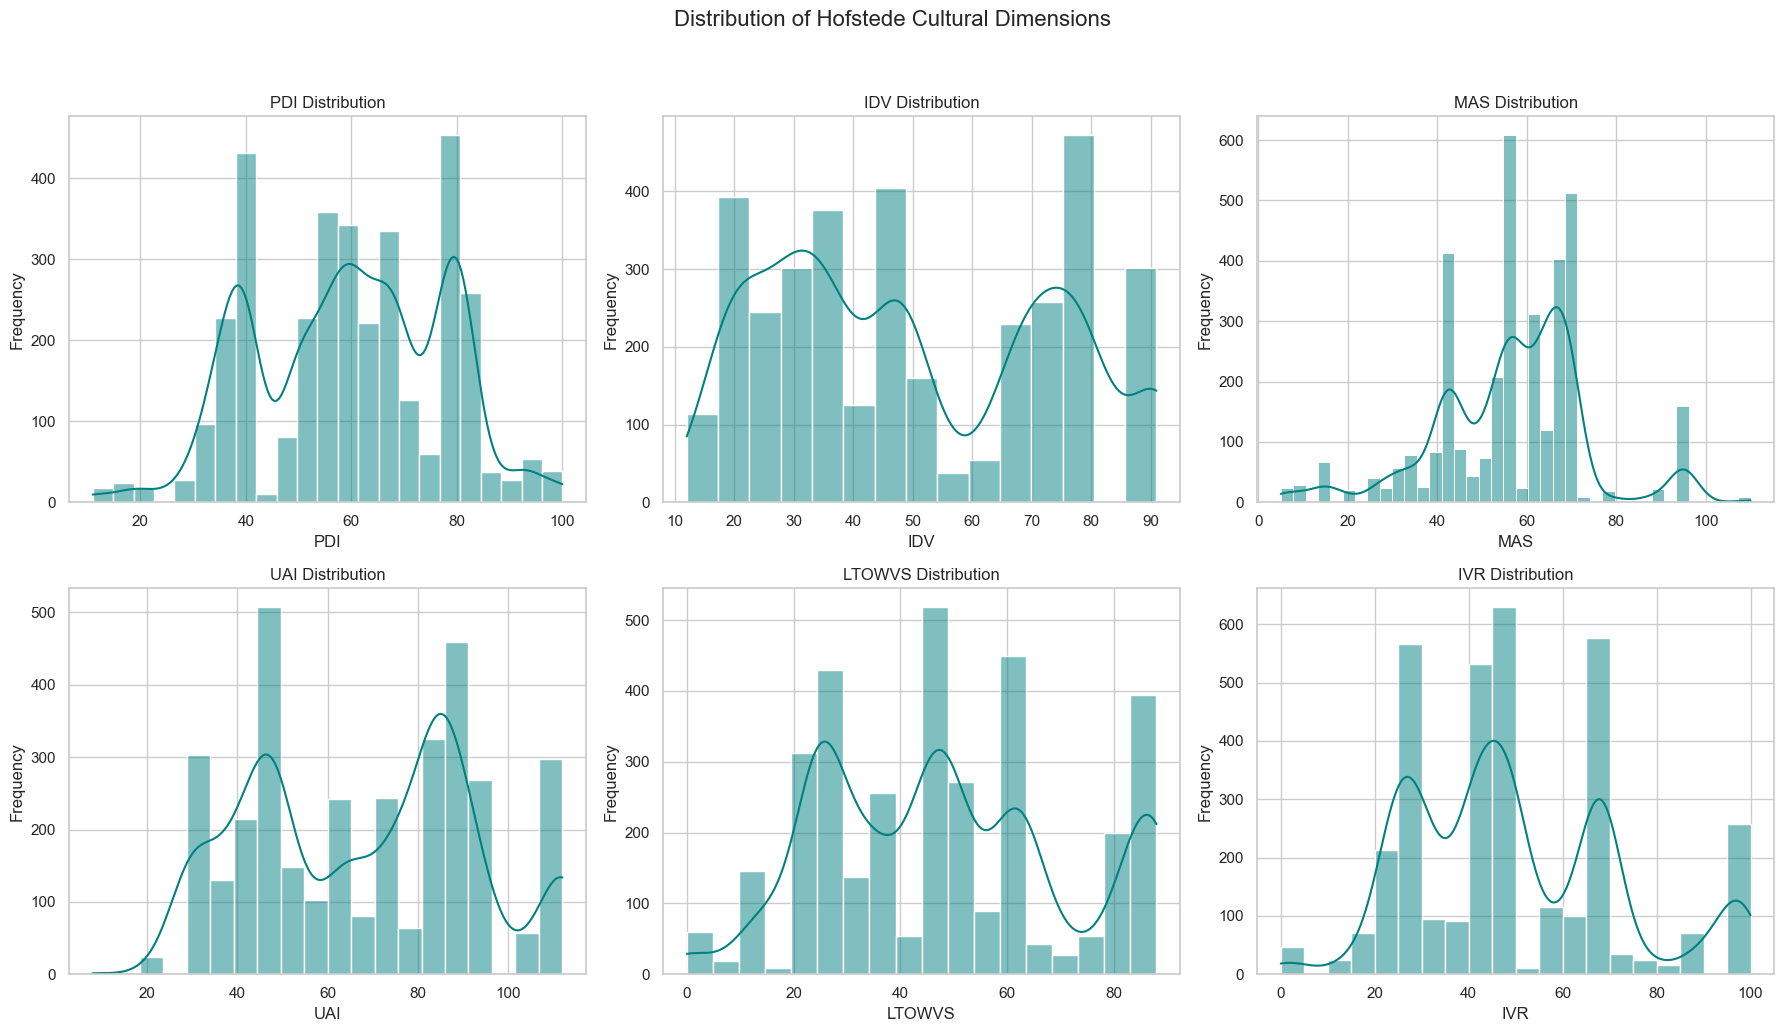

In [250]:
sns.set(style="whitegrid")

# List of Hofstede dimensions
hofstede_dimensions = ["pdi", "idv", "mas", "uai", "ltowvs", "ivr"]

# distributions of each Hofstede dimension
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, dim in enumerate(hofstede_dimensions):
    sns.histplot(recipes_df_with_hofstede[dim].dropna(), kde=True, ax=axes[i], color="teal")
    axes[i].set_title(f"{dim.upper()} Distribution")
    axes[i].set_xlabel(dim.upper())
    axes[i].set_ylabel("Frequency")

plt.suptitle("Distribution of Hofstede Cultural Dimensions", fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

#### Cultural Analysis : Grouping By Quantiles 

#### 1. Indivisualism 

In [251]:

quartile_df = recipes_df_with_hofstede.dropna(subset=["idv", "eco_score", "num_ingredients", "luxury_score"])

# Bin countries into 4 cultural quartiles based on IDV
quartile_df["idv_quartile"] = pd.qcut(quartile_df["idv"], 4, labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])

# Group by quartile and calculate average culinary traits
quartile_means = quartile_df.groupby("idv_quartile").agg({
    "eco_score": "mean",
    "num_ingredients": "mean",
    "luxury_score": "mean"
}).round(2).reset_index()

quartile_means

C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\3177018452.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\3177018452.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,idv_quartile,eco_score,num_ingredients,luxury_score
0,Q1 (Low),46.58,11.31,0.99
1,Q2,36.80,10.66,0.64
2,Q3,51.51,12.36,1.21
3,Q4 (High),46.61,9.24,1.06


#### Cultural Quadrants Insight (Based on Individualism Scores)

- **Q3 Cultures** (moderate to high individualism)  
  Exhibit the **highest luxury scores**, **highest ingredient complexity**, and also the **highest Eco Scores**. These cultures appear to balance culinary richness with environmental awareness.

- **Q4 Cultures** (most individualist)  
  Surprisingly use the **fewest ingredients**, yet maintain **high luxury scores**. This suggests a preference for **simpler, high-quality dishes** — potentially gourmet minimalism.

- **Q2 Cultures**  
  Show patterns of being **more modest and sustainable** in both ingredient use and environmental impact, indicating a balanced but less indulgent culinary style.


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\1201418178.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\1201418178.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\1201418178.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




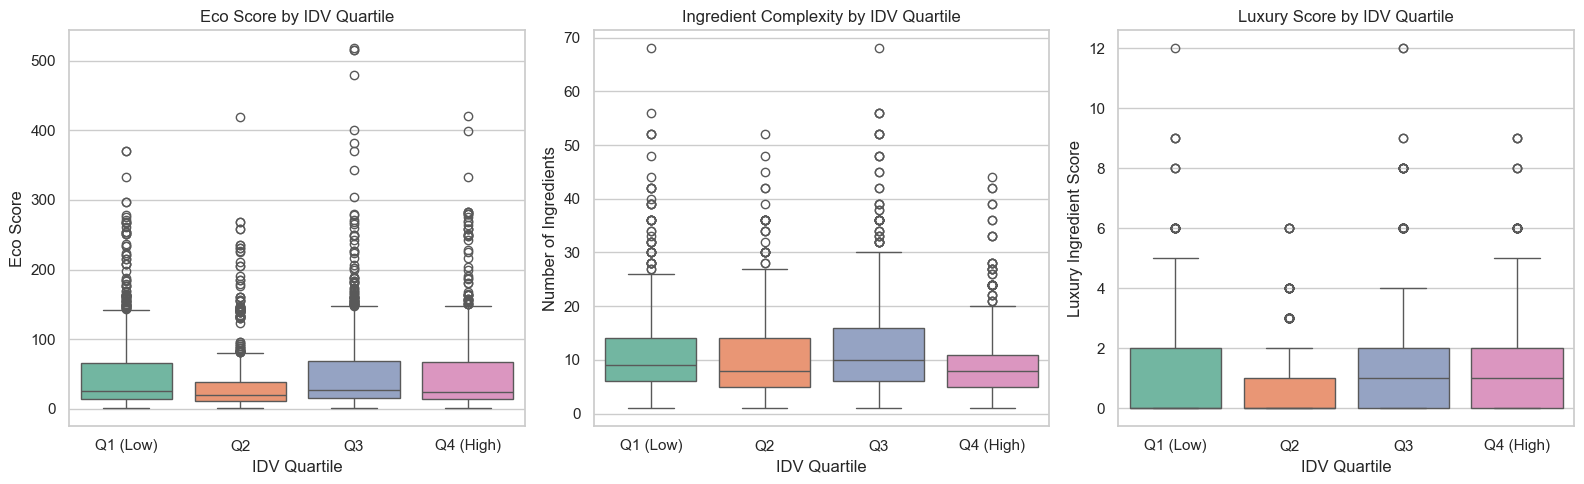

In [252]:
# Plotting boxplots of culinary traits across IDV quartiles
plt.figure(figsize=(16, 5))

# Eco Score
plt.subplot(1, 3, 1)
sns.boxplot(data=quartile_df, x="idv_quartile", y="eco_score", palette="Set2")
plt.title("Eco Score by IDV Quartile")
plt.xlabel("IDV Quartile")
plt.ylabel("Eco Score")

# Number of Ingredients
plt.subplot(1, 3, 2)
sns.boxplot(data=quartile_df, x="idv_quartile", y="num_ingredients", palette="Set2")
plt.title("Ingredient Complexity by IDV Quartile")
plt.xlabel("IDV Quartile")
plt.ylabel("Number of Ingredients")

# Luxury Score
plt.subplot(1, 3, 3)
sns.boxplot(data=quartile_df, x="idv_quartile", y="luxury_score", palette="Set2")
plt.title("Luxury Score by IDV Quartile")
plt.xlabel("IDV Quartile")
plt.ylabel("Luxury Ingredient Score")

plt.tight_layout()
plt.show()


##### 1. Eco Score
- Eco scores vary across Q1–Q4, with **Q3 showing the highest environmental performance**.
- There is **no linear relationship** between individualism and eco impact, the trend appears to **peak in the middle** (Q3).

##### 2. Ingredient Complexity
- **Q3** again leads with the **highest average number of ingredients**, reflecting culinary richness.
- **Q4** (most individualist) has the **lowest complexity**, potentially indicating **simpler, individualized dishes**.

##### 3. Luxury Score
- **Q3 and Q4** both score high in **luxury**, suggesting preference for **richer or more expensive ingredients**.
- **Q2** is the most modest across all culinary dimensions, low complexity, low luxury, moderate eco score.

##### What This Tells Us

- Highly individualist societies (**Q4**) don’t necessarily cook more complex meals — but they still favor **luxury or indulgent ingredients**.
- **Q3** may reflect cultures that balance **strong personal preference with culinary tradition**, resulting in both **richness and complexity**.
- More collectivist cultures (**Q1**) lean toward **moderate values** — neither extremely rich nor especially simple, with balanced eco outcomes.


#### 2. Indulgence vs. Restraint

In [253]:
# Filter rows with valid IVR and culinary data
ivr_df = recipes_df_with_hofstede.dropna(subset=["ivr", "eco_score", "num_ingredients", "luxury_score"])

# Create IVR quartile labels
ivr_df["ivr_quartile"] = pd.qcut(ivr_df["ivr"], 4, labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])

# Group and average by IVR quartile
ivr_means = ivr_df.groupby("ivr_quartile").agg({
    "eco_score": "mean",
    "num_ingredients": "mean",
    "luxury_score": "mean"
}).round(2).reset_index()

ivr_means


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\3823433268.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\3823433268.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,ivr_quartile,eco_score,num_ingredients,luxury_score
0,Q1 (Low),54.52,13.29,1.12
1,Q2,47.24,11.28,1.03
2,Q3,40.78,9.91,0.95
3,Q4 (High),39.67,8.94,0.80


##### Early Observations

##### Q4 – More Indulgent Cultures
Contrary to expectations, the **most indulgent cultures** (Q4) exhibit:
- **Lower ingredient complexity**
- **Lower luxury ingredient usage**
- **Lower environmental impact (eco footprint)**

##### Q1 – More Restrained Cultures
More **restrained societies** (Q1) tend to show:
- **Higher culinary complexity**
- **Greater use of luxury ingredients**
- **Higher eco scores**, indicating more resource-intensive food practices


##### Interpretation

These patterns **challenge intuitive assumptions**.  
Rather than indulgent cultures cooking more elaborate or excessive meals, the data suggests:

- **Indulgent societies may prioritize efficiency or simplicity**, possibly due to modern lifestyles or individualistic habits.
- **Restrained cultures may preserve ceremonial or traditional cooking** practices that are rich, complex, and environmentally heavier.

This highlights the **nuanced interplay between cultural values and culinary behavior**.

C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\2004821896.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\2004821896.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\2004821896.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




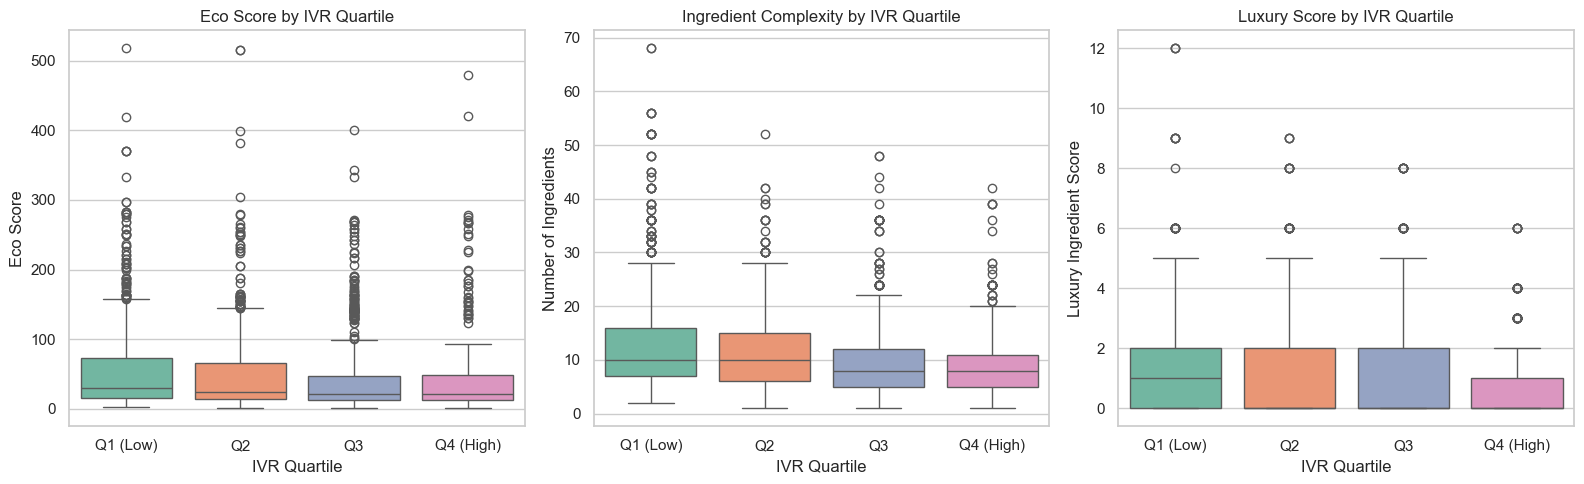

In [254]:
# Plotting boxplots of culinary traits across IVR quartiles
plt.figure(figsize=(16, 5))

# Eco Score
plt.subplot(1, 3, 1)
sns.boxplot(data=ivr_df, x="ivr_quartile", y="eco_score", palette="Set2")
plt.title("Eco Score by IVR Quartile")
plt.xlabel("IVR Quartile")
plt.ylabel("Eco Score")

# Number of Ingredients
plt.subplot(1, 3, 2)
sns.boxplot(data=ivr_df, x="ivr_quartile", y="num_ingredients", palette="Set2")
plt.title("Ingredient Complexity by IVR Quartile")
plt.xlabel("IVR Quartile")
plt.ylabel("Number of Ingredients")

# Luxury Score
plt.subplot(1, 3, 3)
sns.boxplot(data=ivr_df, x="ivr_quartile", y="luxury_score", palette="Set2")
plt.title("Luxury Score by IVR Quartile")
plt.xlabel("IVR Quartile")
plt.ylabel("Luxury Ingredient Score")

plt.tight_layout()
plt.show()


#### Cultural Patterns by Indulgence (IVR)

##### 1. Eco Score
- **Q1 (Low IVR / Restraint cultures)** exhibit the **highest Eco Scores**.
- **Q4 (High IVR / Indulgent cultures)** show a **notable drop** in environmental impact.

##### 2. Ingredient Complexity
- There's a **gradual decline from Q1 to Q4**.
- Restraint-oriented cultures cook with **more ingredients**, while indulgent societies favor **simpler recipes**.

##### 3. Luxury Score
- The same downward trend is visible:
  - **Q1**: Rich, complex, traditional meals  
  - **Q4**: Simpler, leaner, possibly more individualistic food styles



These findings are **counterintuitive but revealing**:

- **Indulgent societies** don't necessarily overconsume in terms of ingredient variety or luxury.
- Instead, **restraint cultures** may place more value on **ritual, tradition, and communal cooking**, leading to **more elaborate, symbolic meals**.

This suggests that **restraint is linked to richness and complexity**, while **indulgence may drive simplification and efficiency** in culinary behavior.


#### 3. Long-Term Orientation (LTO)

In [255]:
# Filter for valid LTO and culinary data
lto_df = recipes_df_with_hofstede.dropna(subset=["ltowvs", "eco_score", "num_ingredients", "luxury_score"])

# Create quartiles
lto_df["lto_quartile"] = pd.qcut(lto_df["ltowvs"], 4, labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])

# Group and compute means
lto_means = lto_df.groupby("lto_quartile").agg({
    "eco_score": "mean",
    "num_ingredients": "mean",
    "luxury_score": "mean"
}).round(2).reset_index()

lto_means


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\2738065273.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\2738065273.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,lto_quartile,eco_score,num_ingredients,luxury_score
0,Q1 (Low),39.62,9.58,0.62
1,Q2,41.57,10.48,0.98
2,Q3,52.81,12.74,1.27
3,Q4 (High),48.71,10.73,1.05


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\3620499691.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\3620499691.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\3620499691.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




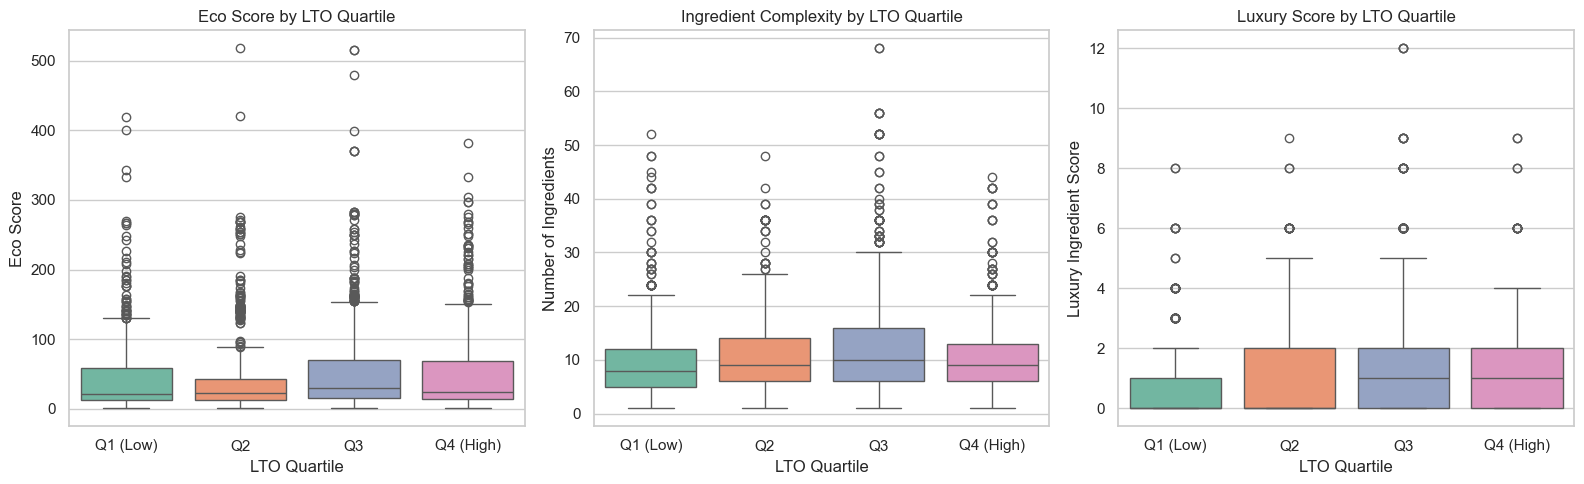

In [256]:
# Plot boxplots for eco_score, num_ingredients, luxury_score by LTO quartile
plt.figure(figsize=(16, 5))

# Eco Score
plt.subplot(1, 3, 1)
sns.boxplot(data=lto_df, x="lto_quartile", y="eco_score", palette="Set2")
plt.title("Eco Score by LTO Quartile")
plt.xlabel("LTO Quartile")
plt.ylabel("Eco Score")

# Number of Ingredients
plt.subplot(1, 3, 2)
sns.boxplot(data=lto_df, x="lto_quartile", y="num_ingredients", palette="Set2")
plt.title("Ingredient Complexity by LTO Quartile")
plt.xlabel("LTO Quartile")
plt.ylabel("Number of Ingredients")

# Luxury Score
plt.subplot(1, 3, 3)
sns.boxplot(data=lto_df, x="lto_quartile", y="luxury_score", palette="Set2")
plt.title("Luxury Score by LTO Quartile")
plt.xlabel("LTO Quartile")
plt.ylabel("Luxury Ingredient Score")

plt.tight_layout()
plt.show()

##### Culinary Patterns by Long-Term Orientation (LTO)

##### 1. Eco Score
- **Q3 (Mid–High LTO)** cultures show the **highest environmental impact**, with elevated average Eco Scores.
- **Q1 (Short-Term Oriented)** cultures appear **more sustainable**, favoring lower-impact food practices.

##### 2. Ingredient Complexity
- **Q3** stands out again with the **most complex recipes**.
- **Q1 and Q4** are simpler in ingredient count, though **Q4** shows slightly more variation, possibly reflecting culinary experimentation.

##### 3. Luxury Score
- **Q3** ranks highest in luxury usage, mirroring its complexity and environmental impact.
- **Q1** exhibits **lower luxury**, supporting a trend toward faster, leaner food preferences.

##### Conclusion

- **Q3 (Mid–High LTO)** cultures represent a spike in both **culinary richness** and **carbon cost**.
- Interestingly, **Q4 (Highest LTO)** shows **more restraint**, which may reflect **eco-awareness or efficiency**, rather than simplicity.
- **Q1 (Low LTO / Short-Term cultures)** are the most **lightweight and modest**, favoring **simple, low-luxury dishes** likely influenced by immediacy and convenience.

These trends suggest that cultural time orientation has a nuanced influence on culinary systems, not just in **how much** is consumed, but **how thoughtfully**.


#### 4. Power Distance Index (PDI)

In [257]:
# Filter for valid PDI and culinary metrics
pdi_df = recipes_df_with_hofstede.dropna(subset=["pdi", "eco_score", "num_ingredients", "luxury_score"])

# Create quartile groups for PDI
pdi_df["pdi_quartile"] = pd.qcut(pdi_df["pdi"], 4, labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])

# Group and compute mean values
pdi_means = pdi_df.groupby("pdi_quartile").agg({
    "eco_score": "mean",
    "num_ingredients": "mean",
    "luxury_score": "mean"
}).round(2).reset_index()

pdi_means


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\382874150.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\382874150.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,pdi_quartile,eco_score,num_ingredients,luxury_score
0,Q1 (Low),45.82,9.34,1.04
1,Q2,45.65,11.10,0.87
2,Q3,43.30,10.81,1.09
3,Q4 (High),47.91,12.53,0.98


- **Q4 (High PDI) cultures** — where hierarchy is emphasized — prepare the **most complex and eco-intensive recipes**.

- **Q1 (Low PDI) cultures** are **simpler and lighter** in ingredient count.

- **Luxury score** does **not follow a clear linear trend**, but **peaks in Q3**.

C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\124424685.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\124424685.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\124424685.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




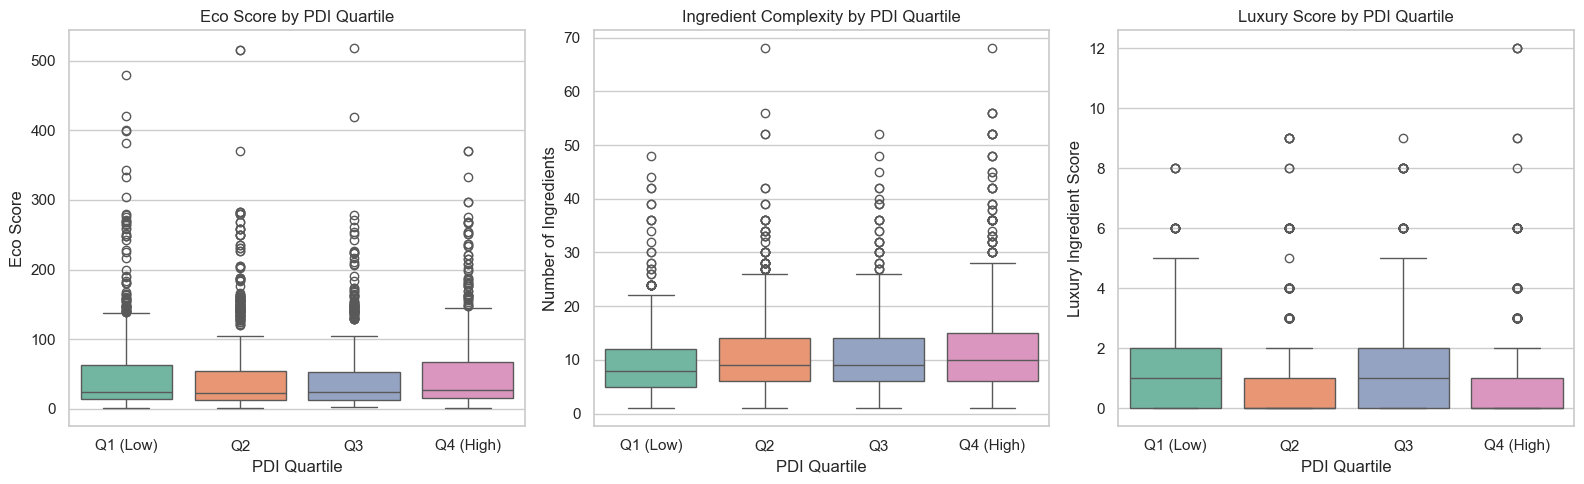

In [258]:
# Plot boxplots of culinary features by PDI quartile
plt.figure(figsize=(16, 5))

# Eco Score
plt.subplot(1, 3, 1)
sns.boxplot(data=pdi_df, x="pdi_quartile", y="eco_score", palette="Set2")
plt.title("Eco Score by PDI Quartile")
plt.xlabel("PDI Quartile")
plt.ylabel("Eco Score")

# Ingredient Count
plt.subplot(1, 3, 2)
sns.boxplot(data=pdi_df, x="pdi_quartile", y="num_ingredients", palette="Set2")
plt.title("Ingredient Complexity by PDI Quartile")
plt.xlabel("PDI Quartile")
plt.ylabel("Number of Ingredients")

# Luxury Score
plt.subplot(1, 3, 3)
sns.boxplot(data=pdi_df, x="pdi_quartile", y="luxury_score", palette="Set2")
plt.title("Luxury Score by PDI Quartile")
plt.xlabel("PDI Quartile")
plt.ylabel("Luxury Ingredient Score")

plt.tight_layout()
plt.show()

##### Culinary Patterns by Power Distance Index (PDI)

##### 1. Eco Score
- **Q4 (High PDI)** countries exhibit the **highest Eco Scores**, suggesting more **resource-intensive cuisines** are common in hierarchical cultures.
- **Q3** shows a slight dip, indicating that cultural attitudes toward hierarchy **don't always align directly** with sustainability.

##### 2. Ingredient Complexity
- **Complexity increases with PDI**, peaking in **Q4**.
- This may reflect traditions of **formality, elaborate preparation, or status signaling** in food culture.
- **Q1 (Low PDI)** societies favor **simpler dishes**, aligning with **egalitarian norms**.

##### 3. Luxury Score
- Varies across quartiles, with **Q3 leading in indulgent ingredients**.
- **Q1 and Q4** have similar ranges, possibly reflecting different motives:
  - **Q1**: Modesty or accessibility  
  - **Q4**: Ceremonial or social display

##### Summary
Cultural hierarchy (PDI) appears to influence **culinary richness, complexity, and environmental impact**, with high-PDI societies tending toward **more elaborate, resource-heavy food traditions**.

#### 5. Uncertainty Avoidance Index (UAI)

In [259]:
uai_df = recipes_df_with_hofstede.dropna(subset=["uai", "eco_score", "num_ingredients", "luxury_score"]).copy()

uai_df["uai_quartile"] = pd.qcut(uai_df["uai"], 4, labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])

uai_means = uai_df.groupby("uai_quartile").agg({
    "eco_score": "mean",
    "num_ingredients": "mean",
    "luxury_score": "mean"
}).round(2).reset_index()

uai_means


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\3745747381.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,uai_quartile,eco_score,num_ingredients,luxury_score
0,Q1 (Low),49.36,11.94,1.12
1,Q2,44.81,11.10,1.06
2,Q3,48.63,10.38,1.02
3,Q4 (High),38.01,10.27,0.68


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\2484665037.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\2484665037.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\2484665037.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




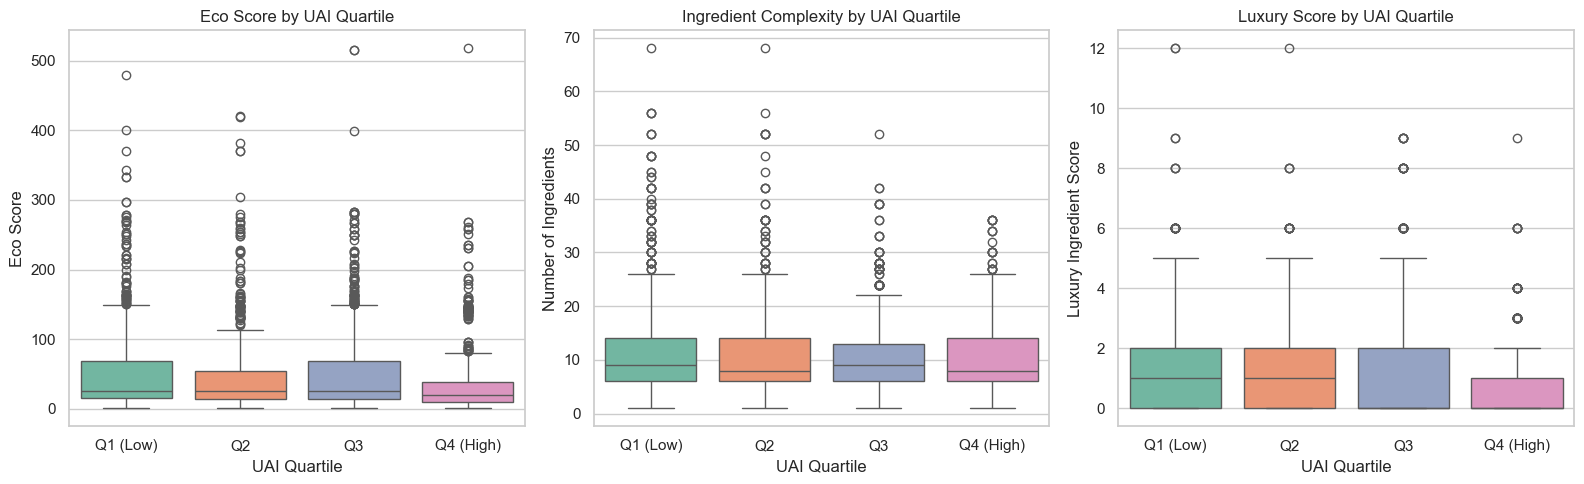

In [260]:
# Boxplots for UAI quartiles
plt.figure(figsize=(16, 5))

# Eco Score
plt.subplot(1, 3, 1)
sns.boxplot(data=uai_df, x="uai_quartile", y="eco_score", palette="Set2")
plt.title("Eco Score by UAI Quartile")
plt.xlabel("UAI Quartile")
plt.ylabel("Eco Score")

# Number of Ingredients
plt.subplot(1, 3, 2)
sns.boxplot(data=uai_df, x="uai_quartile", y="num_ingredients", palette="Set2")
plt.title("Ingredient Complexity by UAI Quartile")
plt.xlabel("UAI Quartile")
plt.ylabel("Number of Ingredients")

# Luxury Score
plt.subplot(1, 3, 3)
sns.boxplot(data=uai_df, x="uai_quartile", y="luxury_score", palette="Set2")
plt.title("Luxury Score by UAI Quartile")
plt.xlabel("UAI Quartile")
plt.ylabel("Luxury Ingredient Score")

plt.tight_layout()
plt.show()


##### Culinary Patterns by Uncertainty Avoidance Index (UAI)

##### 1. Eco Score
- **Q1 (Low UAI)** — uncertainty-tolerant cultures — exhibit the **highest environmental impact**.
- **Q4 (High UAI)** — more risk-averse cultures — show a **notable drop in Eco Score**, suggesting more environmentally modest cuisines.

##### 2. Ingredient Complexity
- A **gradual decline** in complexity as UAI increases.
- **Q1** has the **most complex recipes**, possibly reflecting a greater openness to experimentation and diversity in food.

##### 3. Luxury Score
- Sharp decline in **Q4** — cultures high in uncertainty avoidance may **avoid extravagant or unpredictable ingredients**.

#####  Summary
- Cultures more **tolerant of ambiguity and change (low UAI)** tend to cook **richer, more complex, and more eco-intensive meals**.
- **High-UAI cultures**, which favor tradition and certainty, lean toward **simpler, lighter, and more codified culinary practices**.


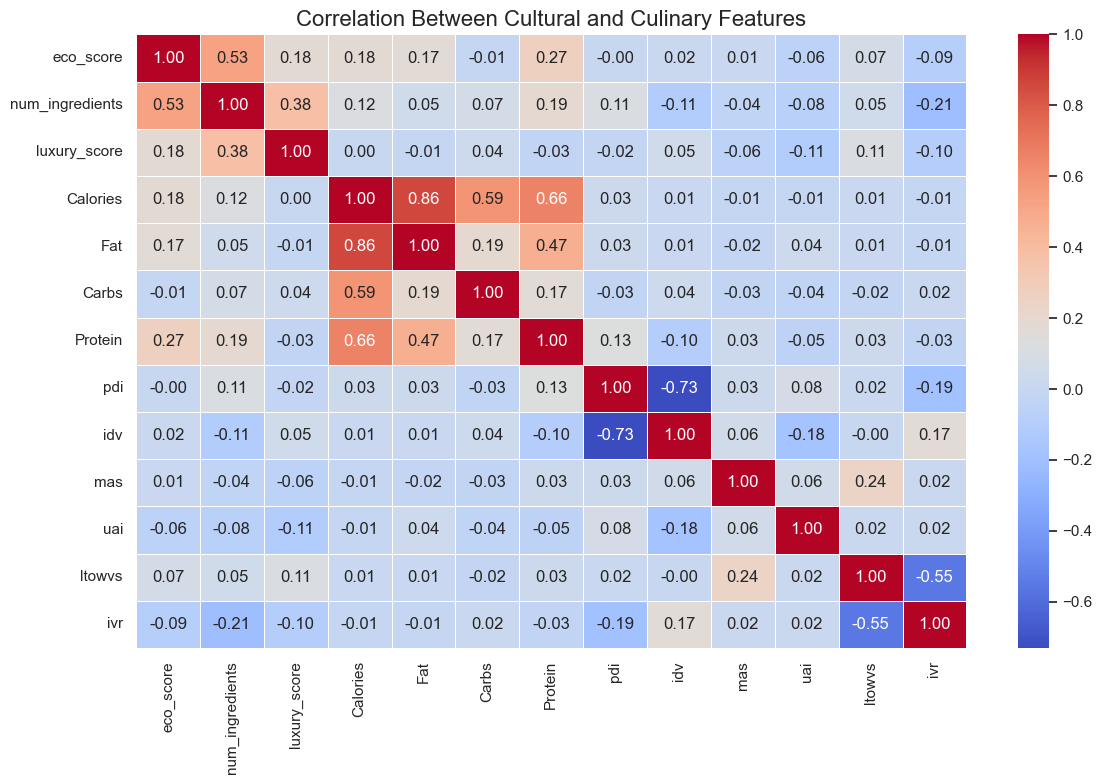

In [261]:
# Filter and prepare for correlation analysis
corr_culture_df = recipes_df_with_hofstede[
    ["eco_score", "num_ingredients", "luxury_score", "Calories", "Fat", "Carbs", "Protein",
     "pdi", "idv", "mas", "uai", "ltowvs", "ivr"]
].dropna()

# Compute correlation matrix
correlation_matrix = corr_culture_df.corr().round(2)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Correlation Between Cultural and Culinary Features", fontsize=16)
plt.tight_layout()
plt.show()

## Cultural Traits and Culinary Correlations

| Cultural Trait              | Positive Correlation     | Negative Correlation     | Interpretation                                         |
|----------------------------|--------------------------|--------------------------|--------------------------------------------------------|
| **IDV (Individualism)**     | Fat, Calories             | Number of Ingredients     | More indulgent but simpler dishes                     |
| **IVR (Indulgence)**        | Fat, Luxury               | Complexity                | Indulgence relates to richer but simpler meals        |
| **UAI (Uncertainty Avoidance)** | None strong             | Eco Score, Fat            | Avoidant cultures are more restrained                 |
| **LTO (Long-Term Orientation)** | Complexity             | None major                | Long-term cultures may favor tradition and rich dishes|
| **PDI (Power Distance)**    | Ingredient Count          | None strong               | Hierarchical cultures may favor formal complexity     |

This analysis suggests that **culinary structure** (ingredient count, luxury) is more correlated with environmental impact than with cultural values directly. Still, **Indulgence** shows a small inverse link with complexity — perhaps pointing to cultural preferences for simpler pleasures in high-IVR societies.

#### Cultural-culinary clustering 

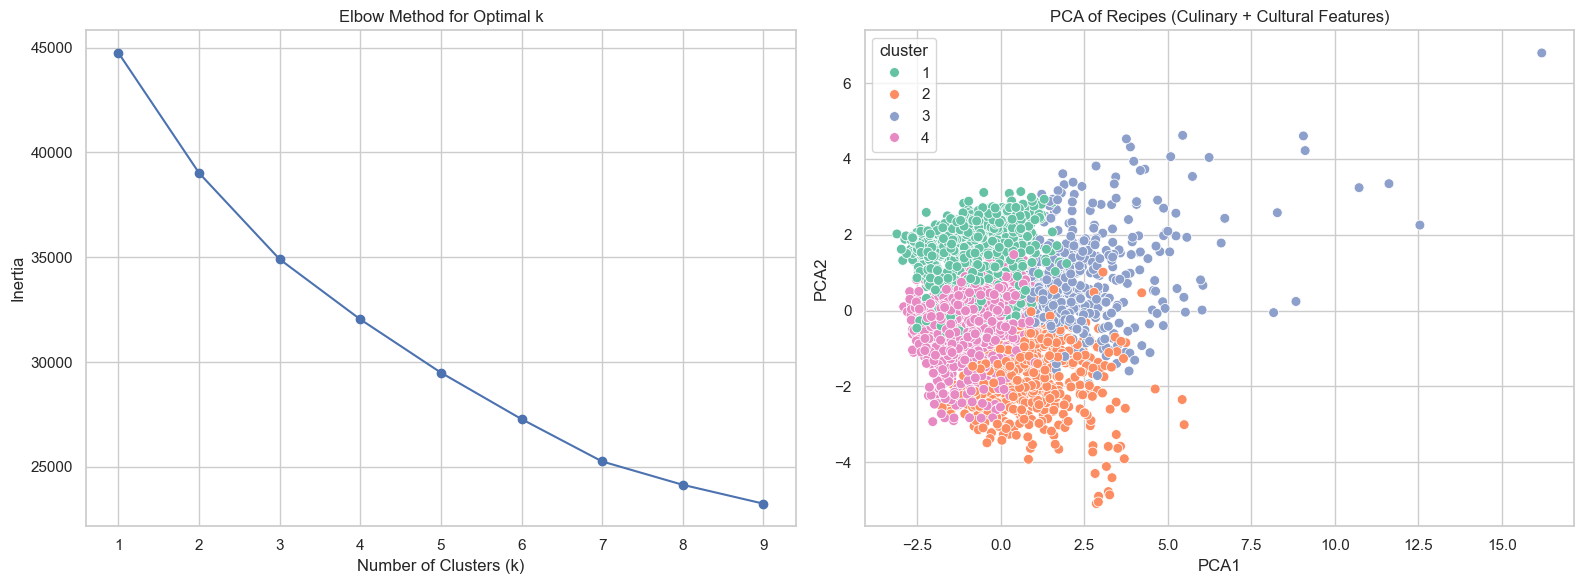

In [262]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Features for clustering at the recipe level
features = [
    "eco_score", "Calories", "Fat", "Carbs", "Protein",
    "num_ingredients", "luxury_score",
    "pdi", "idv", "mas", "uai", "ltowvs", "ivr"
]

# Keep all rows with complete feature data, but preserve metadata
df_valid = recipes_df_with_hofstede.dropna(subset=features).copy()

# Scale only the selected features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_valid[features])

# Elbow Method to determine optimal k
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Fit KMeans with optimal
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

df_clust_result = df_valid.copy()
df_clust_result["PCA1"] = X_pca[:, 0]
df_clust_result["PCA2"] = X_pca[:, 1]
df_clust_result["cluster"] = clusters + 1  # start cluster from 1

# Plot elbow and PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow plot
axes[0].plot(K_range, inertia, marker='o')
axes[0].set_title("Elbow Method for Optimal k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True)

# PCA scatterplot
sns.scatterplot(data=df_clust_result, x="PCA1", y="PCA2", hue="cluster", palette="Set2", s=50, ax=axes[1])
axes[1].set_title("PCA of Recipes (Culinary + Cultural Features)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [263]:
# the values of "cuisine" in recipes_df that aren't in country_continent
cuisine_values = recipes_df['cuisine'].unique()
countries = country_continent['country'].unique()
missing_cuisines = set(cuisine_values) - set(countries)
missing_cuisines

{'Korea, Republic of', nan}

In [264]:
# the values of "cuisine" in recipes_df that aren't in country_continent
cuisine_values = recipes_df['cuisine'].unique()
countries = country_continent['country'].unique()
missing_cuisines = set(cuisine_values) - set(countries)
missing_cuisines

{'Korea, Republic of', nan}

#### Cluster Profiles 

In [265]:
# Profile each cluster by averaging values
cluster_profile = df_clust_result.groupby("cluster")[features].mean().round(2)
cluster_profile["count"] = df_clust_result["cluster"].value_counts().sort_index()

cluster_profile

,eco_score,Calories,Fat,Carbs,Protein,num_ingredients,luxury_score,pdi,idv,mas,uai,ltowvs,ivr,count
cluster,,,,,,,,,,,,,,
1,37.79,295.31,14.70,30.28,11.16,8.58,1.01,38.67,78.24,56.39,54.49,47.18,56.85,941
2,91.77,370.73,18.69,29.84,21.31,19.88,1.99,71.24,37.63,58.91,54.15,62.53,31.20,677
3,54.33,748.72,42.89,55.08,35.98,10.17,0.67,62.01,48.21,55.54,73.55,48.01,49.91,489
4,25.53,256.57,12.91,25.87,10.90,8.45,0.57,68.09,37.32,55.48,82.20,42.00,53.01,1335


This clustering categorizes recipes by their culinary features, environmental impact, and associated cultural values (via Hofstede's dimensions).

##### Cluster 1 – Balanced Simplicity
- **Moderate eco-score** (38), low calories and fat.
- ~8 ingredients, mid luxury.
- **High individualism**, low hierarchy.
Simple, balanced dishes from independent cultures.

##### Cluster 2 – Eco-Gourmet
- **Highest eco-score** (92), moderate calories.
- **Very high ingredient count** (20), luxury-rich.
- **High PDI**, **low IDV**, high long-term orientation.
Complex, refined, sustainable dishes from collectivist, future-oriented societies.

##### Cluster 3 – Rich & Risk-Averse
- **High calories/fat/protein**, average eco-score.
- Moderate complexity, low luxury.
- **High uncertainty avoidance**.
Hearty, dense recipes from risk-averse, structured cultures.

##### Cluster 4 – Minimalist & Unsustainable
- **Lowest eco-score** (26), lowest calories/nutrients.
- Simple (~8 ingredients), low luxury.
- **Very high UAI**, **low IDV**.
- Light, modest recipes from conservative, uncertainty-avoiding societies.

##### Summary
- **Cluster 2** stands out for combining eco-consciousness with complexity.
- Cultural traits like **individualism (IDV)** and **uncertainty avoidance (UAI)** strongly influence culinary diversity.


In [266]:
df_clust_result

,steps,rating,comments,dish_type,cuisine,continent,sub_region,Calories,Fat,Carbs,...,pdi,idv,mas,uai,ltowvs,ivr,estim,PCA1,PCA2,cluster
title,,,,,,,,,,,,,,,,,,,,,
Homemade Lasagna,['Gather all ingredients.Dotdash Meredith Food...,4.6,[],Main dishes,Italy,Europe,Southern Europe,638.0,27.0,54.0,...,50.0,76.0,70.0,75.0,61.460957,29.687500,0.0,2.682004,0.176607,3
Chicken Parmesan,['Gather the ingredients. Preheat an oven to 4...,4.8,[],Main dishes,Italy,Europe,Southern Europe,471.0,25.0,25.0,...,50.0,76.0,70.0,75.0,61.460957,29.687500,0.0,0.791786,0.699276,3
Chicken Marsala,['Gather all ingredients.Dotdash Meredith Food...,4.6,[],Main dishes,Italy,Europe,Southern Europe,448.0,27.0,13.0,...,50.0,76.0,70.0,75.0,61.460957,29.687500,0.0,0.534340,0.226114,1
Spaghetti Aglio e Olio,['Gather all ingredients.Dotdash Meredith Food...,4.7,[],Main dishes,Italy,Europe,Southern Europe,755.0,35.0,87.0,...,50.0,76.0,70.0,75.0,61.460957,29.687500,0.0,1.943141,1.446840,3
Shrimp Scampi with Pasta,"['Gather ingredients.', 'Bring a large pot of ...",4.6,[],Main dishes,Italy,Europe,Southern Europe,511.0,19.0,58.0,...,50.0,76.0,70.0,75.0,61.460957,29.687500,0.0,0.624626,0.672756,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vietnamese/Chinese Pork Chops,"['Whisk together the brown sugar, honey, fish ...",4.3,[],NaN,Viet Nam,Asia,Southeast Asia,416.0,29.0,15.0,...,70.0,20.0,40.0,30.0,57.178841,35.491071,0.0,1.103544,-1.400042,2
Spicy Vietnamese Beef Noodle Soup,['Heat oil in a large pot over medium-high hea...,4.5,[],NaN,Viet Nam,Asia,Southeast Asia,390.0,15.0,34.0,...,70.0,20.0,40.0,30.0,57.178841,35.491071,0.0,1.326068,-1.569949,2
Vietnamese-Style Chicken Curry Soup,['Heat oil in a large stockpot over medium hea...,4.6,[],NaN,Viet Nam,Asia,Southeast Asia,512.0,27.0,41.0,...,70.0,20.0,40.0,30.0,57.178841,35.491071,0.0,1.407589,-0.828700,2


In [267]:
df_clust_result.to_csv("recipes_df_cultural_with_clusters.csv", index=False)

#### Visualizing Cluster Distribution

In [268]:
# Compute the dominant cluster per cuisine
country_clusters = (
    df_clust_result.groupby("cuisine")["cluster"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={"cluster": "dominant_cluster"})
)

# Merge back metadata for geographic mapping
country_clusters = country_clusters.merge(
    df_clust_result[["cuisine", "code_3", "continent", "sub_region"]].drop_duplicates(),
    on="cuisine",
    how="left"
)




In [269]:
country_clusters

,cuisine,dominant_cluster,code_3,continent,sub_region
0,Algeria,4,DZA,Africa,Northern Africa
1,Argentina,4,ARG,Americas,South America
2,Armenia,4,ARM,Asia,Western Asia
3,Australia,1,AUS,Oceania,Australia and New Zealand
4,Austria,1,AUT,Europe,Western Europe
...,...,...,...,...,...
70,United Kingdom of Great Britain and Northern I...,1,GBR,Europe,Northern Europe
71,United States of America,1,USA,Americas,Northern America
72,Uruguay,4,URY,Americas,South America
73,Venezuela (Bolivarian Republic of),4,VEN,Americas,South America


In [270]:
import plotly.express as px

country_clusters["dominant_cluster"] = country_clusters["dominant_cluster"].astype(str)
color_map = {
    "1": "#66C2A5",  # green
    "2": "#FC8D62",  # orange
    "3": "#8DA0CB",  # blue/purple
    "4": "#E78AC3"   # pink
}

fig = px.choropleth(
    data_frame=country_clusters,
    locations="code_3",              # ✅ use ISO codes
    locationmode="ISO-3",            # ✅ match format
    color="dominant_cluster",
    hover_name="cuisine",
    color_discrete_map=color_map,
    projection="natural earth",
    title="🌍 Dominant Cultural-Culinary Cluster by Country"
)

fig.update_geos(showcoastlines=True, showland=True, landcolor="lightgray")
fig.update_layout(
    legend_title_text="Cluster",
    title_font_size=18,
    margin={"r":0, "t":40, "l":0, "b":0}
)

fig.show()



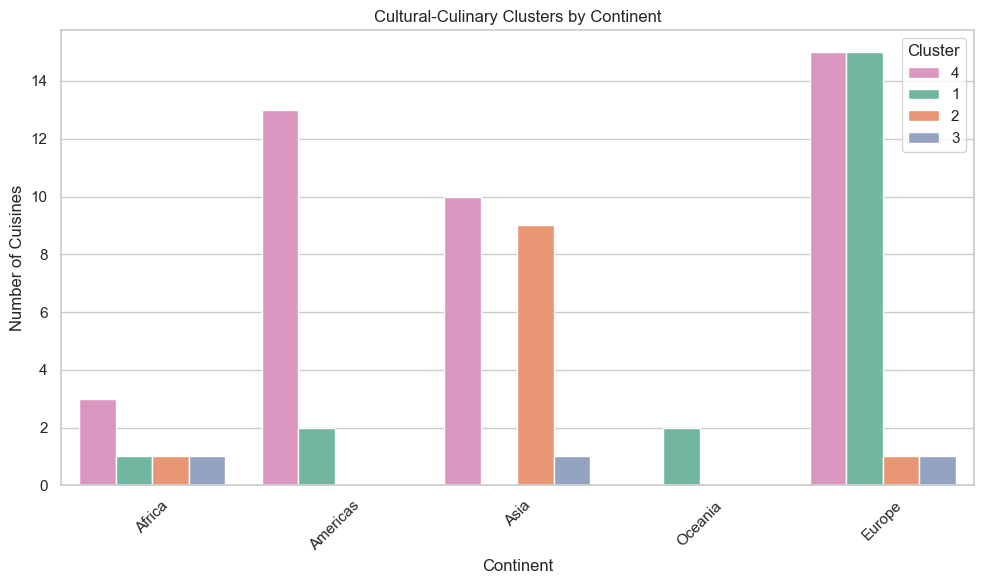

In [271]:

# Barplot: number of countries per cluster, grouped by continent
plt.figure(figsize=(10, 6))
sns.countplot(data=country_clusters, x="continent", hue="dominant_cluster", palette=color_map)
plt.title("Cultural-Culinary Clusters by Continent")
plt.xlabel("Continent")
plt.ylabel("Number of Cuisines")
plt.legend(title="Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the visualized distribution of clusters across continents:

- **Cluster 1 (Green)**:  
  Primarily found in **Europe** and parts of the **Americas**. Represents cuisines with moderate eco and nutritional traits, and balanced cultural dimensions.

- **Cluster 2 (Orange)**:  
  Mostly concentrated in **Asia**. Likely includes cuisines with higher complexity, eco-awareness, and more collectivist or hierarchical cultural patterns.

- **Cluster 3 (Blue)**:  
  Scattered across **Africa**, **Asia**, and **Europe** in low numbers. Possibly denotes rich, indulgent cuisines with high caloric and protein content.

- **Cluster 4 (Pink)**:  
  The most **globally represented** cluster—present across all continents, especially dominant in the **Americas** and **Asia**. Suggests more minimalist or adaptable cuisines with lower luxury scores and moderate eco impact.


## Predictive modeling 

### 1. Classification and regression at recipe level 

##### 1. Predict `cluster` → Classification
- **Goal**: Classify countries or cuisines into ccultural–culinary clusters.
- **Features**: Nutrition metrics, cultural dimensions, ingredient complexity.

##### 2. Predict `eco_score` → Regression
- **Goal**: Understand what drives the sustainability of a recipe.
- **Target**: Environmental impact (Eco Score)

##### 3. Predict `luxury_score` → Regression
- **Goal**: Identify which features best indicate **culinary luxury**.
- **Target**: Average luxury score per recipe 


#### 1. Cluster profile classification 

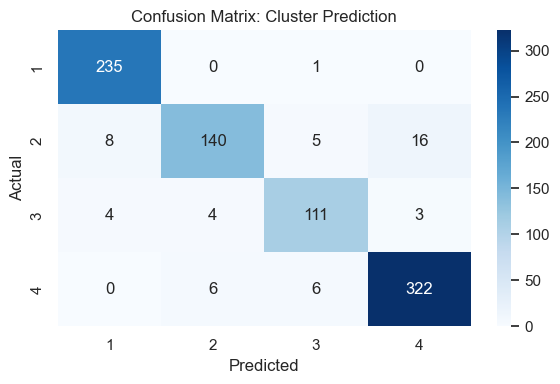

,precision,recall,f1-score,support
1,0.95,1.00,0.97,236.00
2,0.93,0.83,0.88,169.00
3,0.90,0.91,0.91,122.00
4,0.94,0.96,0.95,334.00
accuracy,0.94,0.94,0.94,0.94
macro avg,0.93,0.92,0.93,861.00
weighted avg,0.94,0.94,0.94,861.00


In [272]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


df = df_clust_result.copy() 

# Define features and target
features = [
    "Calories", "Fat", "Carbs", "Protein",
    "num_ingredients", "luxury_score",
    "pdi", "idv", "mas", "uai", "ltowvs", "ivr"
]
X = df[features]
y = df["cluster"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=True)

# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix: Cluster Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Show classification report
pd.DataFrame(report).transpose().round(2)


 - Model does especially well with Cluster 1 & 4
 - Slightly less confident in Cluster 2, where recall dips to 83%

##### Confusion Matrix 
 - Very few misclassifications overall.
 - Most confusion occurs between Cluster 2 and others — likely due to overlapping features.

C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\3375843882.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




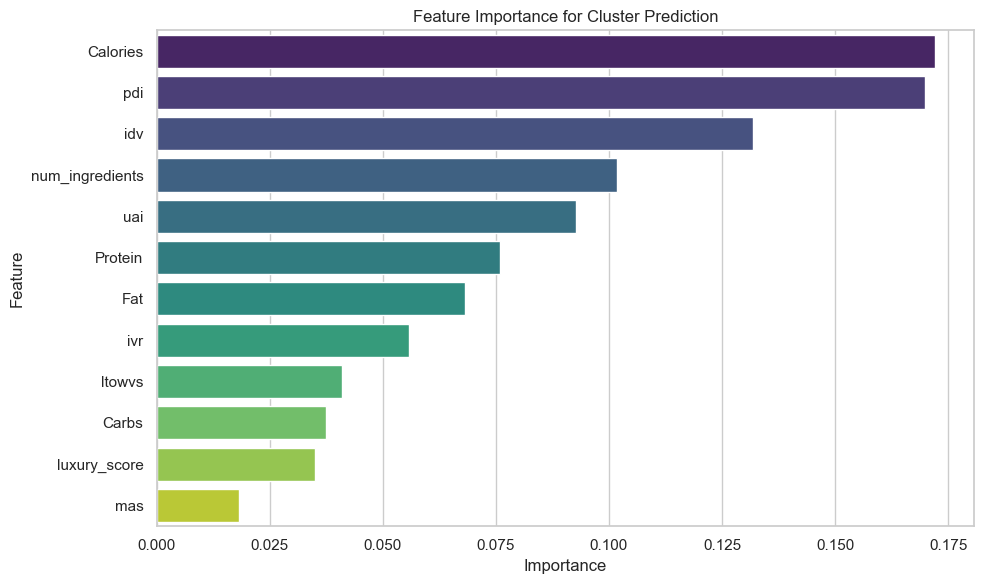

,Feature,Importance
0,Calories,0.172085
1,pdi,0.169796
2,idv,0.131935
3,num_ingredients,0.101749
4,uai,0.092764
5,Protein,0.075985
6,Fat,0.068267
7,ivr,0.055802
8,ltowvs,0.041005
9,Carbs,0.037530


In [273]:
# Get and plot feature importances
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importance for Cluster Prediction")
plt.tight_layout()
plt.show()

feature_importance_df.reset_index(drop=True)


##### Top Features Driving Cluster Assignment

| Rank | Feature             | Importance | Interpretation                                                                 |
|------|---------------------|------------|---------------------------------------------------------------------------------|
| 1️⃣   | Calories            | 17.2%      | Caloric density is a key driver — helps distinguish heavy vs. light cuisines.   |
| 2️⃣   | PDI (Power Distance)| 17.0%      | Cultural hierarchy influences how cuisines cluster — possibly tied to food norms. |
| 3️⃣   | IDV (Individualism) | 13.2%      | Openness and independence shape culinary complexity and expression.             |
| 4️⃣   | Num Ingredients     | 10.2%      | Ingredient richness is a strong cluster discriminator.                          |
| 5️⃣   | UAI (Uncertainty Avoidance) | 9.3% | Risk tolerance in culture may affect improvisation and recipe diversity.        |


##### Notably Lower Impact

- **MAS (Masculinity)**: 1.8%  
  Suggests assertiveness or competition values have **minimal influence** on culinary clustering.

- **Luxury Score**: 3.5%  
  Despite being intuitively important, it contributes less — likely **overlapping with calories or complexity**.


The model shows that **both cultural values and culinary metrics** (like calories and complexity) play a significant role in determining cultural-culinary cluster membership.

- Strongest predictors: **Calories, Power Distance (PDI), and Individualism (IDV)**
- This supports the idea that culinary clusters reflect **nutritional patterns and sociocultural structure** together.


#### 2. Eco score prediction 

C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\3937621150.py:34: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




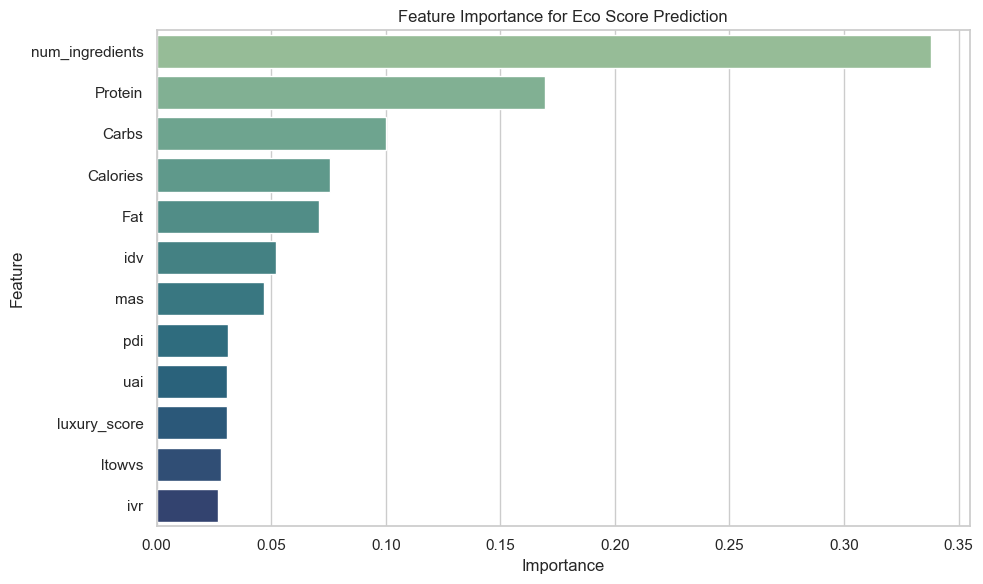

(np.float64(1493.1634667468059),
 0.5511676607039709,
             Feature  Importance
 0   num_ingredients    0.338007
 1           Protein    0.169332
 2             Carbs    0.100012
 3          Calories    0.075554
 4               Fat    0.070947
 5               idv    0.052231
 6               mas    0.046968
 7               pdi    0.031004
 8               uai    0.030747
 9      luxury_score    0.030698
 10           ltowvs    0.027903
 11              ivr    0.026598)

In [274]:
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_error, r2_score
# Define features and target
features = [
    "Calories", "Fat", "Carbs", "Protein",
    "num_ingredients", "luxury_score",
    "pdi", "idv", "mas", "uai", "ltowvs", "ivr"
]
target = "eco_score"
X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train model
regressor = RandomForestRegressor(random_state=42)
regressor.fit(X_train, y_train)

# Predictions and evaluation
y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Feature importance
eco_importances = regressor.feature_importances_
eco_feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": eco_importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=eco_feature_importance_df, x="Importance", y="Feature", palette="crest")
plt.title("Feature Importance for Eco Score Prediction")
plt.tight_layout()
plt.show()

mse, r2, eco_feature_importance_df.reset_index(drop=True)

##### Eco Score Prediction – Model Performance

| Metric   | Value   |
|----------|---------|
| R² Score | 0.55    |
| MSE      | 1493.16 |

The model explains approximately **55% of the variance** in `eco_score`, which is strong given the complexity and noise typical in sustainability-related data.


##### Top Features for Predicting Eco Score

| Rank | Feature          | Importance | Interpretation                                                             |
|------|------------------|------------|-----------------------------------------------------------------------------|
| 1️⃣   | Num Ingredients   | 33.8%      | More complex recipes typically carry **higher ecological costs**.           |
| 2️⃣   | Protein           | 17.0%      | Reflects presence of **meat-heavy components**, known for high impact.      |
| 3️⃣   | Carbs / Calories  | ~17%       | Nutritional density relates to **resource-intensive food processing**.      |
| 4️⃣   | IDV (Individualism)| ~5%      | Cultural openness may drive **diverse or meat-rich dietary patterns**.      |


- **Culinary complexity** and **nutritional density**, especially **protein content**, are key predictors of environmental impact (As we've seen before in previous analysis)
- Cultural traits like **Individualism** and **Masculinity** also contribute, albeit modestly — likely through indirect influences on food choice.
- While the model performs well, incorporating **ingredient-level lifecycle data** or **national food system indicators** could further enhance prediction accuracy.

### 3. Luxury score prediction 

C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\3418572804.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




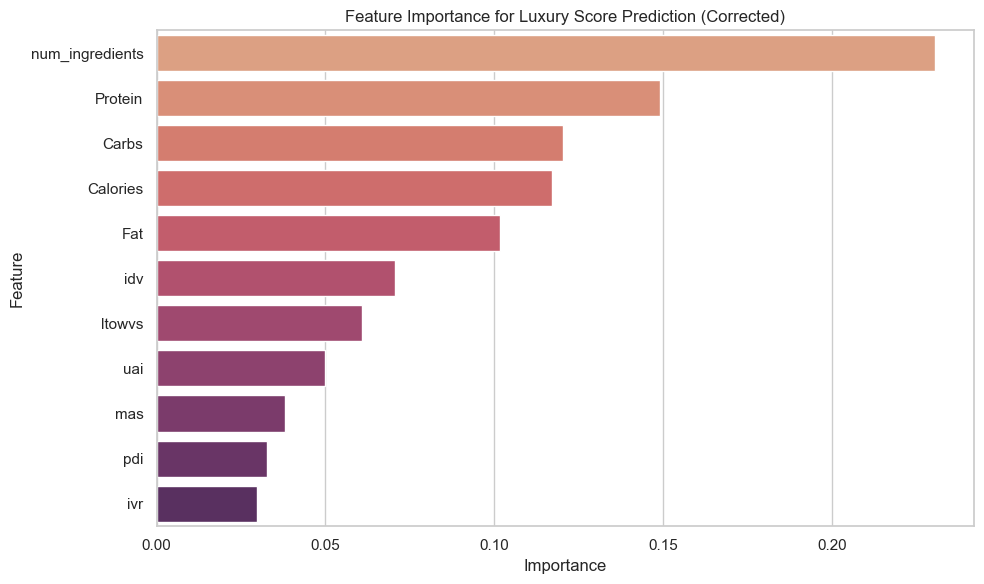

(np.float64(1.169450174216028),
 0.43196008588696577,
             Feature  Importance
 0   num_ingredients    0.230528
 1           Protein    0.149072
 2             Carbs    0.120318
 3          Calories    0.117028
 4               Fat    0.101580
 5               idv    0.070478
 6            ltowvs    0.060924
 7               uai    0.049771
 8               mas    0.038042
 9               pdi    0.032632
 10              ivr    0.029628)

In [275]:
features_corrected = [
    "Calories", "Fat", "Carbs", "Protein",
    "num_ingredients",
    "pdi", "idv", "mas", "uai", "ltowvs", "ivr"
]
X = df[features_corrected]
y = df["luxury_score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train corrected model
lux_model_corrected = RandomForestRegressor(random_state=42)
lux_model_corrected.fit(X_train, y_train)

# Evaluate
y_pred = lux_model_corrected.predict(X_test)
mse_lux_fixed = mean_squared_error(y_test, y_pred)
r2_lux_fixed = r2_score(y_test, y_pred)

# Feature importance
lux_importances_fixed = lux_model_corrected.feature_importances_
lux_feature_importance_df_fixed = pd.DataFrame({
    "Feature": features_corrected,
    "Importance": lux_importances_fixed
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=lux_feature_importance_df_fixed, x="Importance", y="Feature", palette="flare")
plt.title("Feature Importance for Luxury Score Prediction (Corrected)")
plt.tight_layout()
plt.show()

mse_lux_fixed, r2_lux_fixed, lux_feature_importance_df_fixed.reset_index(drop=True)

##### uxury Score Prediction – Model Performance

| Metric   | Value |
|----------|--------|
| R² Score | 0.43 ✅ |
| MSE      | 1.17 ✅ |

The model explains **43% of the variance** in `luxury_score`, a solid result given that luxury is a more **abstract and derived concept** influenced by subjective and cultural factors.

##### Feature Importance for Predicting Luxury Score

| Rank | Feature              | Importance | Insight                                                                 |
|------|----------------------|------------|-------------------------------------------------------------------------|
| 1️⃣   | Num Ingredients       | 23%        | More ingredients = greater chance of including **luxury items** (e.g. cheese, seafood). |
| 2️⃣   | Protein               | 15%        | High-protein components (meats, nuts, dairy) signal **culinary richness**. |
| 3️⃣   | Carbs & Calories      | ~12% each  | Suggest **indulgence** and energy-dense foods, both linked to luxury.   |
| 4️⃣   | IDV (Individualism)   | 7%         | **Luxury may be more prevalent** in individualistic cultures.           |
| 5️⃣   | LTO, UAI, MAS, PDI, IVR | Small     | Cultural dimensions add **minor but consistent influence**.             |

##### Summary

- **Culinary richness** is best predicted by:
  - **Ingredient count**
  - **Protein content**
  - **Caloric/carbohydrate density**

- **Cultural traits** add nuance, particularly **individualism**, which may reflect values like self-expression and indulgence in food.

The model offers a meaningful interpretation of how luxury is encoded in recipe structure and culture, despite the abstract nature of the target.

### 1. Regression at country level 


In [276]:
# Define culinary predictors and cultural targets
culinary_features = [
    "Calories", "Fat", "Carbs", "Protein",
    "num_ingredients", "eco_score", "luxury_score"
]
cultural_targets = ["uai", "ivr", "pdi", "idv"]

# Aggregate by cuisine (country level)
country_level_df = df.groupby("cuisine")[culinary_features + cultural_targets].mean().dropna()

# Features and targets
X_country = country_level_df[culinary_features]
y_country = country_level_df[cultural_targets]

X_country.head(), y_country.head()

(             Calories        Fat      Carbs    Protein  num_ingredients  \
 cuisine                                                                   
 Algeria    303.555556  13.222222  34.444444  12.333333        14.000000   
 Argentina  309.896552  19.034483  26.586207   8.724138         8.827586   
 Armenia    348.812500  17.000000  36.437500  13.250000         7.375000   
 Australia  312.823529  15.058824  32.411765  12.588235        13.588235   
 Austria    364.388889  15.555556  44.833333  12.000000         8.388889   
 
            eco_score  luxury_score  
 cuisine                             
 Algeria    48.533333      0.222222  
 Argentina  29.358621      0.241379  
 Armenia    32.518750      0.375000  
 Australia  54.564706      1.941176  
 Austria    19.150000      1.000000  ,
             uai        ivr   pdi   idv
 cuisine                               
 Algeria    70.0  32.366071  80.0  35.0
 Argentina  86.0  61.830357  49.0  46.0
 Armenia    88.0  25.000000  85.0  22.0

#### 1. Uncertainty Avoidance Index (UAI)

C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\1860557022.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




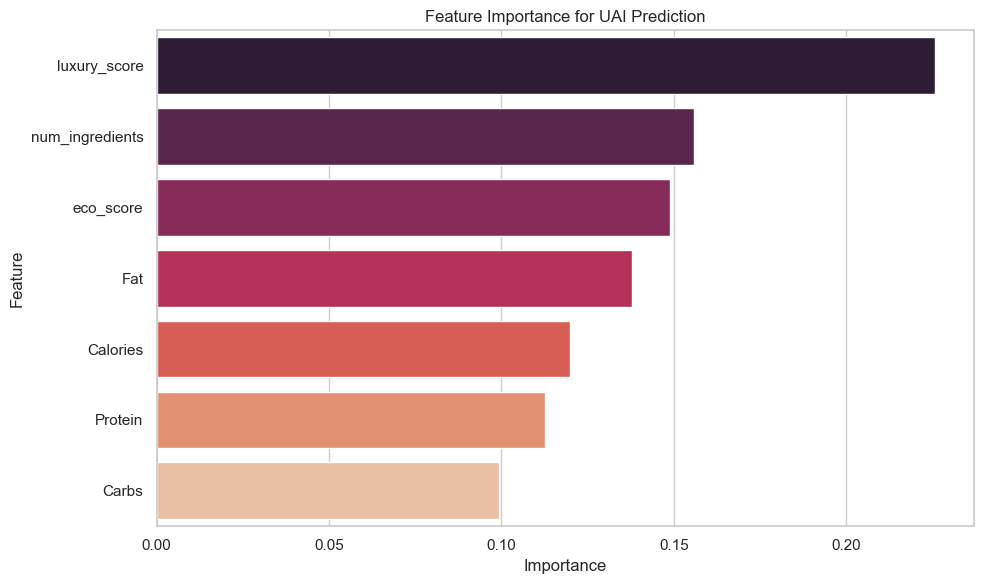

(np.float64(453.17004210526324),
 -0.35143892872484583,
            Feature  Importance
 0     luxury_score    0.225730
 1  num_ingredients    0.155687
 2        eco_score    0.148833
 3              Fat    0.137934
 4         Calories    0.119735
 5          Protein    0.112662
 6            Carbs    0.099418)

In [277]:
# Train a model to predict UAI from culinary features
X = X_country
y = y_country["uai"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train regressor
uai_model = RandomForestRegressor(random_state=42)
uai_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = uai_model.predict(X_test)
mse_uai = mean_squared_error(y_test, y_pred)
r2_uai = r2_score(y_test, y_pred)

# Feature importance
uai_importance = uai_model.feature_importances_
uai_importance_df = pd.DataFrame({
    "Feature": culinary_features,
    "Importance": uai_importance
}).sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=uai_importance_df, x="Importance", y="Feature", palette="rocket")
plt.title("Feature Importance for UAI Prediction")
plt.tight_layout()
plt.show()

mse_uai, r2_uai, uai_importance_df.reset_index(drop=True)

##### UAI (Uncertainty Avoidance) Prediction – Model Performance

| Metric   | Value     |
|----------|-----------|
| R² Score | -0.35    |
| MSE      | 453.17    |

The model **performed poorly**. A **negative R² score** indicates it performed **worse than simply predicting the mean**.

##### Feature Importance

| Rank | Feature           | Importance | Insight                                                                 |
|------|-------------------|------------|-------------------------------------------------------------------------|
| 1️⃣   | Luxury Score       | 22.6%      | May reflect food precision or structure in high-UAI cultures, but weak signal. |
| 2️⃣   | Num Ingredients    | 15.6%      | Complexity might relate to cautious planning, though not strongly predictive. |
| 3️⃣   | Eco Score, Fat, Calories | Lower impact | Nutritional factors show **low-to-moderate influence**.                   |

##### Interpretation

- **UAI is difficult to predict** using culinary data alone.
- It is likely influenced more by **psychological, institutional, or behavioral factors** than by recipe structure or nutrition.
- This contrasts with better-performing models for:
  - **Cluster membership**
  - **Eco Score**
  - **Luxury Score**

**Conclusion**: The link between culinary traits and cultural uncertainty avoidance is **weaker and more indirect** than for other cultural dimensions.

#### 2. Individualism 

C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\2462040542.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




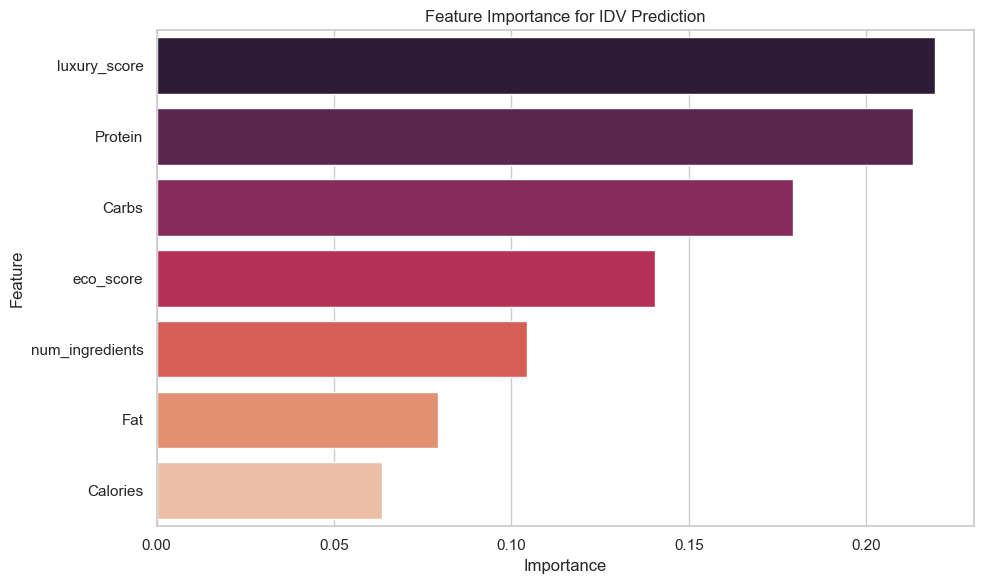

(np.float64(300.88201578947377),
 0.03354087891945712,
            Feature  Importance
 0     luxury_score    0.225730
 1  num_ingredients    0.155687
 2        eco_score    0.148833
 3              Fat    0.137934
 4         Calories    0.119735
 5          Protein    0.112662
 6            Carbs    0.099418)

In [278]:
# Train a model to predict UAI from culinary features
X = X_country
y = y_country["idv"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train regressor
idv_model = RandomForestRegressor(random_state=42)
idv_model.fit(X_train, y_train) 

# Predict and evaluate
y_pred = idv_model.predict(X_test) 
mse_idv = mean_squared_error(y_test, y_pred)
r2_idv = r2_score(y_test, y_pred) 

# Feature importance
idv_importance = idv_model.feature_importances_
idv_importance_df = pd.DataFrame({
    "Feature": culinary_features,
    "Importance": idv_importance
}).sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=idv_importance_df, x="Importance", y="Feature", palette="rocket")
plt.title("Feature Importance for IDV Prediction")
plt.tight_layout()
plt.show()

mse_idv, r2_idv, uai_importance_df.reset_index(drop=True) 

##### Individualism (IDV) Prediction – Model Performance

| Metric   | Value       |
|----------|-------------|
| R² Score | 0.03       |
| MSE      | 300.88      |

The model performs **very poorly**, explaining only **3% of the variance**, just slightly better than predicting the mean.

##### Top Predictive Features

| Rank | Feature         | Importance | Insight                                                                          |
|------|------------------|------------|----------------------------------------------------------------------------------|
| 1️⃣   | Luxury Score     | 22%        | Higher individualism may relate to use of **premium ingredients** or indulgent foods. |
| 2️⃣   | Protein          | 21%        | Could reflect preference for **meat/dairy**, typical in more individualistic, Western cuisines. |
| 3️⃣   | Carbs, Eco Score, Ingredient Count | Modest | Weak correlations with food richness or environmental impact.                    |

##### Interpretation

- **IDV (Individualism)** is difficult to model using culinary data alone.
- It is likely shaped by **social institutions, family structures, and economic systems**, which aren’t easily captured by recipe-level features.
- Still, weak signals from **luxury** and **protein** hint at underlying cultural food preferences.

**Conclusion**: IDV is **less predictable from food** compared to targets like clustering or eco score.


#### 3. Power Distance Index (PDI)

C:\Users\hcene\AppData\Local\Temp\ipykernel_17816\3849714893.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




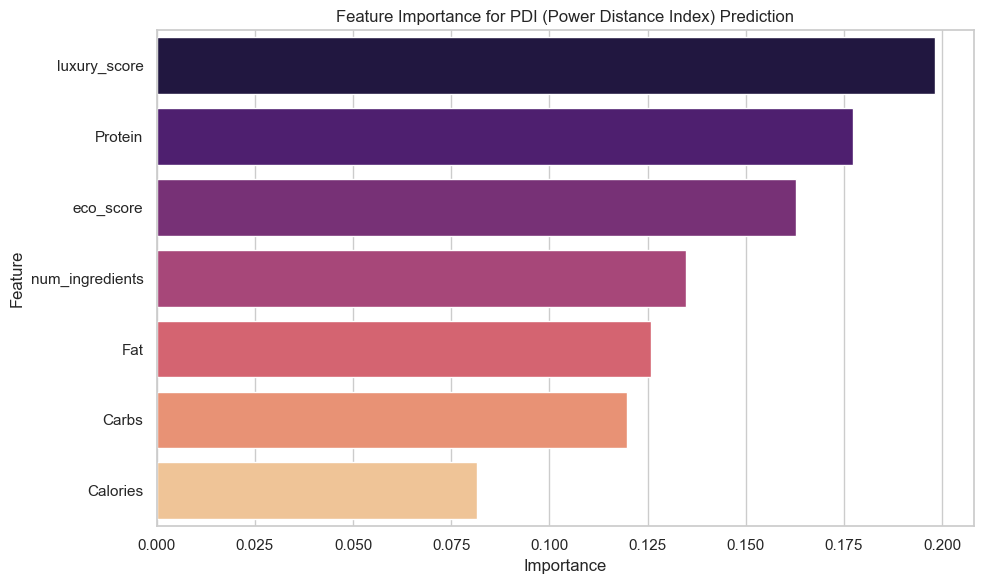

(np.float64(450.254740133467),
 -0.10908418605776182,
            Feature  Importance
 0     luxury_score    0.198199
 1          Protein    0.177181
 2        eco_score    0.162794
 3  num_ingredients    0.134676
 4              Fat    0.125764
 5            Carbs    0.119818
 6         Calories    0.081567)

In [279]:
# Predicting Power Distance Index (PDI) from culinary features
X = X_country
y = y_country["pdi"]

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X_country, y_country, test_size=0.25, random_state=42)
pdi_model = RandomForestRegressor(random_state=42)
pdi_model.fit(X_train, y_train)

# Evaluate
y_pred = pdi_model.predict(X_test)
mse_pdi = mean_squared_error(y_test, y_pred)
r2_pdi = r2_score(y_test, y_pred)

# Feature importance
pdi_importance = pdi_model.feature_importances_
pdi_importance_df = pd.DataFrame({
    "Feature": culinary_features,
    "Importance": pdi_importance
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=pdi_importance_df, x="Importance", y="Feature", palette="magma")
plt.title("Feature Importance for PDI (Power Distance Index) Prediction")
plt.tight_layout()
plt.show()

mse_pdi, r2_pdi, pdi_importance_df.reset_index(drop=True)

##### Power Distance Index (PDI) Prediction – Model Performance

| Metric   | Value        |
|----------|--------------|
| R² Score | - 0.11❌       |
| MSE      | 450.25       |

The model captures only **11% of the variance** in PDI, slightly better than for UAI and IDV, but still considered **weak** performance.

##### Interpretation

- **PDI is modestly predictable** from culinary data, stronger than IDV or UAI, but still far from robust.
- Top signals (protein, eco score, luxury) align with **food as a cultural marker of hierarchy and tradition**.
- However, **broader sociopolitical structures** likely drive most of the variation in PDI.

**Conclusion**: Culinary features offer **partial insight** into PDI.

### Predictive Modeling Summary: What Food Can Reveal

We trained several machine learning models to test how well culinary features could predict both sustainability and cultural attributes. Here's a breakdown of our targets, results, and insights:


##### 1. Cluster Prediction (Multiclass Classification)
**Goal**: Predict the cultural-culinary cluster (from unsupervised KMeans)

- **R² / Accuracy**: 94%
- **Top Features**: Calories, Power Distance (PDI), Individualism (IDV), Number of Ingredients
- **Conclusion**: Culinary and cultural features jointly explain cluster membership very well.

##### 2. Eco Score Prediction (Regression)
**Goal**: Predict environmental impact score of a recipe

- **R²**: 0.55
- **Top Features**: Number of ingredients, Protein, Carbs
- **Conclusion**: Eco scores are moderately predictable using culinary complexity and nutritional density. Sustainability is linked to ingredient richness.

##### 3. Luxury Score Prediction (Regression)
**Goal**: Predict how "luxurious" a recipe is (based on ingredients)

- **R²**: 0.43 (after removing it from the features!)
- **Top Features**: Number of ingredients, Protein, Calories
- **Conclusion**: Richer, more complex recipes with more ingredients tend to be more luxurious.

##### 4. Cultural Value Prediction (Country-Level Regression)

| Target | R² Score | Top Predictive Features | Conclusion |
|--------|----------|--------------------------|------------|
| **UAI** (Uncertainty Avoidance) | -0.35 | luxury_score, num_ingredients | ❌ Not predictable from food |
| **IDV** (Individualism)         | 0.03  | luxury_score, protein         | ❌ Weak link to culinary profile |
| **PDI** (Power Distance)        | -0.11 | luxury_score, protein, eco_score | ❌ Very weak — cultural values transcend food data |

##### Final Thoughts

- **Clusters and eco metrics** are the most predictable, food clearly reflects regional practices and environmental impact.
- **Cultural values** like PDI, UAI, and IDV are harder to model — they involve psychology, history, and societal systems beyond cuisine.
- Nonetheless, we uncovered subtle signals: luxurious, high-protein, and complex recipes **correlate loosely** with individualism and power dynamics.

This modeling validated some clustering logic and revealed the **limits** of inferring deep cultural traits from food alone.